# Data Ingestion

In [2]:
import pandas as pd

df = pd.read_csv('../data_raw/raw_diabetes.csv')

In [3]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# Data Analysis

Compare Mean and Max of Population and Sample

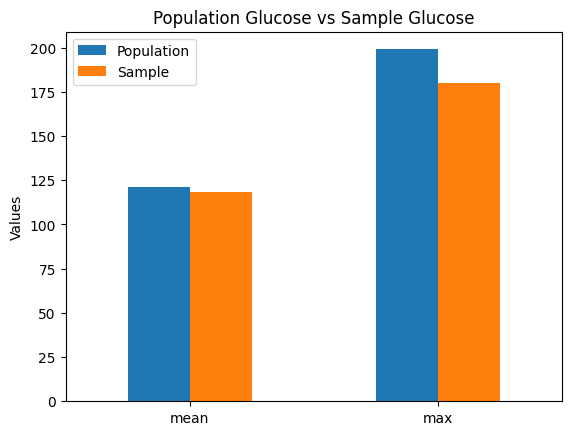

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Create a data frame that has 25 randomly pulled samples from the original data frame
df_25 = df.sample(n=25, random_state=1)

# Find the max and mean of glucose in the sample and population
pop_stats = df['Glucose'].agg(['mean', 'max'])
sample_stats = df_25['Glucose'].agg(['mean', 'max'])
comparison = pd.DataFrame({'Population': pop_stats, 'Sample': sample_stats})

# Plot the data on a chart
ax = comparison.plot(kind='bar', ylabel='Values', title='Population Glucose vs Sample Glucose', rot=0)
plt.show()

# Save the plot to 'results'
fig = ax.get_figure()
fig.savefig('../results/Population vs Sample Glucose')

98th Percentile

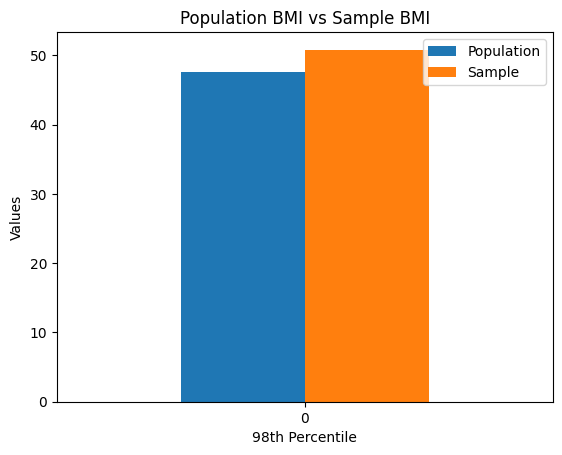

In [5]:
# Find the 98th percentile of BMI in the population and sample
pop_BMI = df['BMI'].quantile(0.98)
sample_BMI = df_25['BMI'].quantile(0.98)
compare_BMI = pd.DataFrame([{'Population': pop_BMI, 'Sample': sample_BMI}])

# Plot the comparison on a chart
ax = compare_BMI.plot(kind='bar', ylabel='Values', title='Population BMI vs Sample BMI', rot=0, xlabel='98th Percentile')
plt.show()

# Save the plot to 'results'
fig = ax.get_figure()
fig.savefig('../results/Population vs Sample BMI')

Bootstrapping

In [6]:
# Empty list for bootstrapped samples
boots_samples = []

# Bootstrap
for i in range(500):
    # Sample with replacement
    sample = df.sample(n=150, replace=True, random_state=i)
    boots_samples.append(sample)

# Mean, Standard Deviation, and Percentile for Blood Pressure in Bootstrapped Data
b_mean = 0
b_sd = 0
b_percentile = 0
for i in boots_samples:
    b_mean += i['BloodPressure'].mean()
    b_sd += i['BloodPressure'].std()
    b_percentile += i['BloodPressure'].quantile(0.98)

# Find the average of each stat
b_stats = {
    'Mean': b_mean / len(boots_samples),
    'Standard Deviation': b_sd / len(boots_samples),
    'Percentile': b_percentile / len(boots_samples)
}

# Find the Mean, Standard Deviation, and Percentile for Blood Pressure in the Population
p_stats = {
    'Mean': df['BloodPressure'].mean(),
    'Standard Deviation': df['BloodPressure'].std(),
    'Percentile': df['BloodPressure'].quantile(0.98)
}

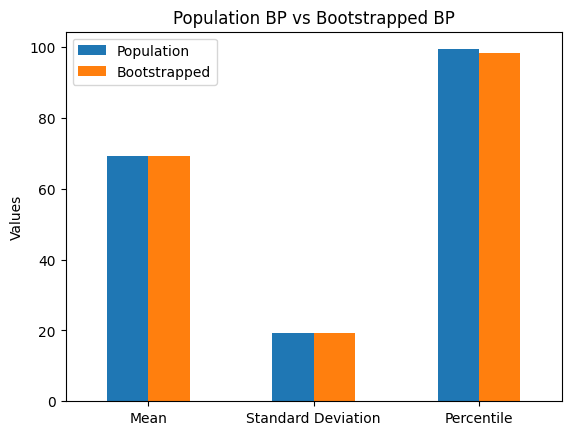

In [7]:
# Compare Bootstrapped Stats to the Population Stats in chart
compare_bp = pd.DataFrame({'Population': p_stats, 'Bootstrapped': b_stats})

# Plot the comparison on a chart
ax = compare_bp.plot(kind='bar', ylabel='Values', title='Population BP vs Bootstrapped BP', rot=0)
plt.show()

# Save the plot to 'results'
fig = ax.get_figure()
fig.savefig('../results/Population vs Bootstrapped Blood Pressure')